# Repeat Customer Analysis

In [17]:
import pandas as pd
import numpy as np
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt

import os
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# data processing classes
from src.customer_features import CustomerFeatureEngineer
from src.product_features import ProductFeatureEngineer
from src.recommendation_training import RecommendationTrainingBuilder


In [18]:
base_path = Path("../data/processed")
articles_clean_df = pd.read_csv(base_path / "articles_hm_cleaned.csv")
customers_clean_df = pd.read_csv(base_path / "customer_hm_cleaned.csv")
transactions_clean_df = pd.read_csv(base_path / "transactions_hm_cleaned.csv")

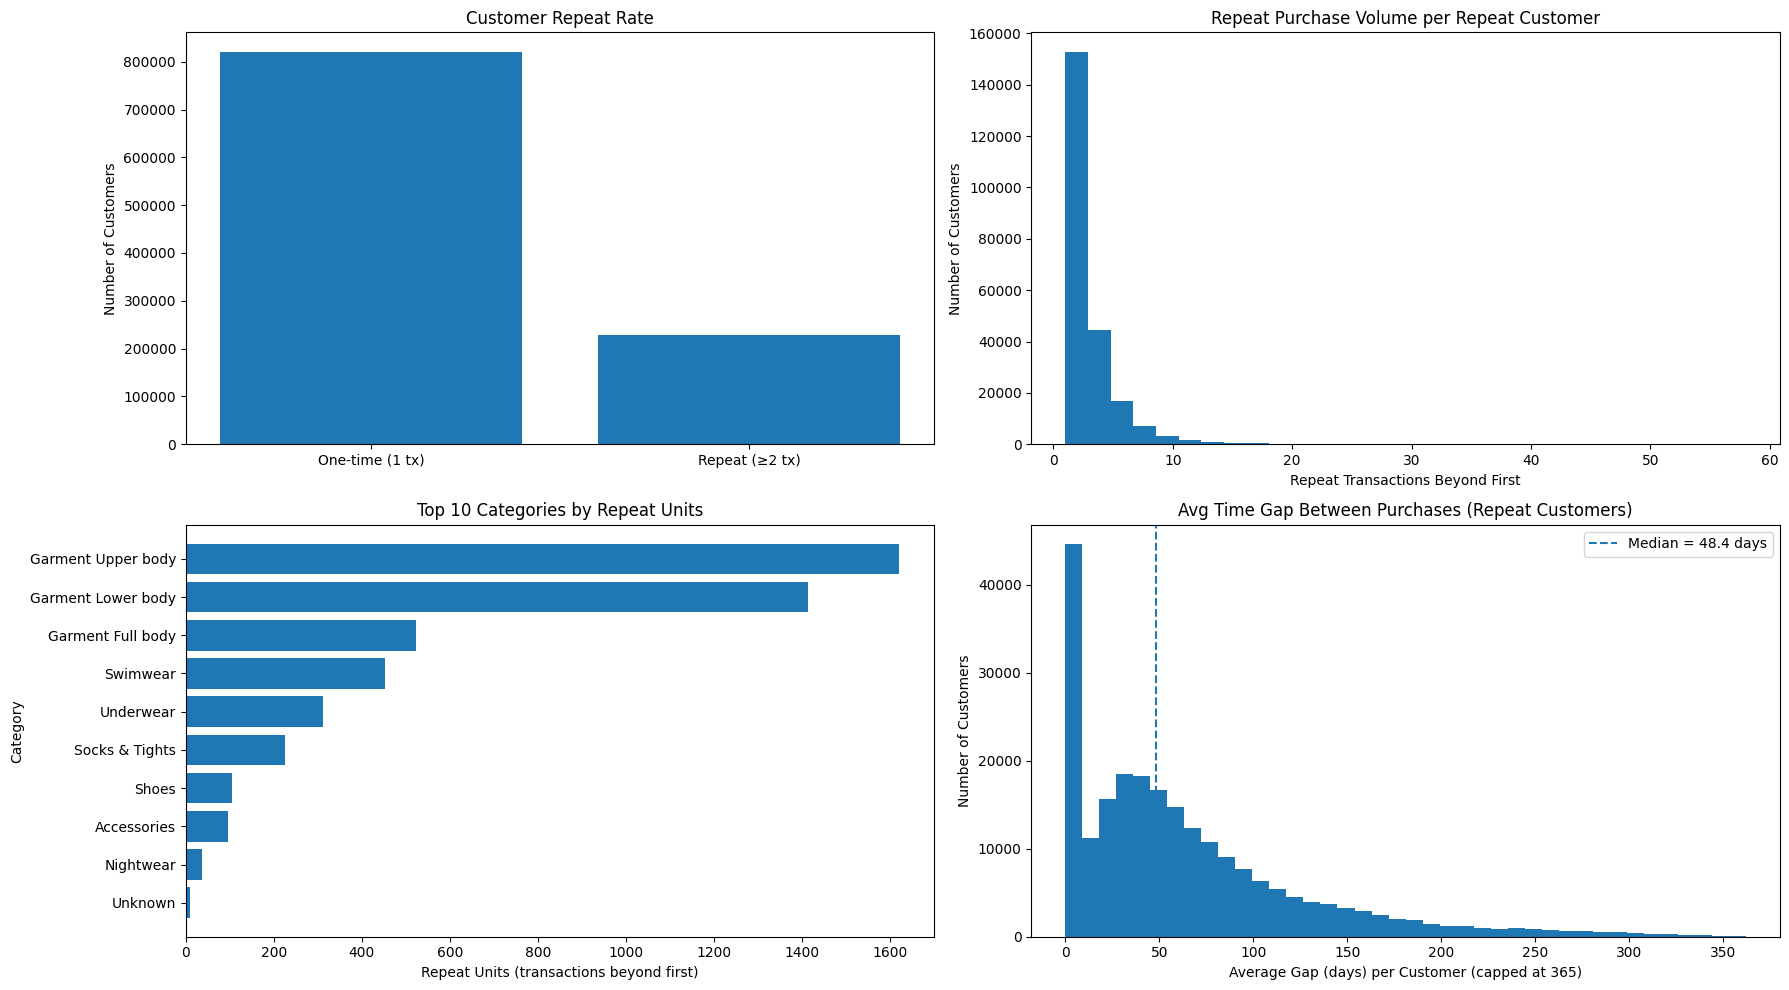

In [20]:
import matplotlib.pyplot as plt

def style_ax(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)

base_tx = transactions_clean_df.dropna(subset=["customer_id", "article_id", "t_dat"]).copy()
base_tx["t_dat"] = pd.to_datetime(base_tx["t_dat"], errors="coerce")

cust_tx_count = base_tx.groupby("customer_id").size().rename("tx_count")
n_all_customers = customers_clean_df["customer_id"].nunique()
repeat_customers = cust_tx_count[cust_tx_count >= 2].index
n_repeat_customers = len(repeat_customers)
one_time_customers = n_all_customers - n_repeat_customers
repeat_rate_vals = [one_time_customers, n_repeat_customers]
repeat_rate_labels = ["One-time (1 tx)", "Repeat (≥2 tx)"]

repeat_volume_per_customer = cust_tx_count.loc[repeat_customers] - 1

cust_dates = base_tx.sort_values(["customer_id", "t_dat"]).copy()
cust_dates["gap_days"] = cust_dates.groupby("customer_id")["t_dat"].diff().dt.days

repeat_gap_per_customer = (
    cust_dates[cust_dates["customer_id"].isin(repeat_customers)]
    .groupby("customer_id")["gap_days"]
    .mean()
    .dropna()
)
gaps = repeat_gap_per_customer.dropna()
median_gap = gaps.median() if len(gaps) else None

category_col = "product_group_name"
repeat_units = (
    base_tx.groupby(["customer_id", "article_id"])
    .size()
    .rename("n")
    .reset_index()
)
repeat_units["repeat_units"] = (repeat_units["n"] - 1).clip(lower=0)
repeat_units = repeat_units[repeat_units["repeat_units"] > 0]

repeat_with_cat = repeat_units.merge(
    articles_clean_df[["article_id", category_col]],
    on="article_id",
    how="left"
)
cat_repeat = (
    repeat_with_cat.groupby(category_col, dropna=False)["repeat_units"]
    .sum()
    .sort_values(ascending=False)
)

top_k = 10
top_cat_repeat = cat_repeat.head(top_k).sort_values()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# (1) Repeat rate bar
axes[0, 0].bar(repeat_rate_labels, repeat_rate_vals)
style_ax(axes[0, 0], "Customer Repeat Rate", ylabel="Number of Customers")
axes[0, 0].tick_params(axis="x", rotation=0)

# (2) Repeat volume distribution
axes[0, 1].hist(repeat_volume_per_customer, bins=30)
style_ax(
    axes[0, 1],
    "Repeat Purchase Volume per Repeat Customer",
    xlabel="Repeat Transactions Beyond First",
    ylabel="Number of Customers",
)

# (3) Top repeat categories (KPI #3)
axes[1, 0].barh(top_cat_repeat.index.astype(str), top_cat_repeat.values)
style_ax(
    axes[1, 0],
    f"Top {top_k} Categories by Repeat Units",
    xlabel="Repeat Units (transactions beyond first)",
    ylabel="Category",
)

# (4) Average time gap distribution (KPI #4)
axes[1, 1].hist(gaps.clip(upper=365), bins=40)
style_ax(
    axes[1, 1],
    "Avg Time Gap Between Purchases (Repeat Customers)",
    xlabel="Average Gap (days) per Customer (capped at 365)",
    ylabel="Number of Customers",
)
if median_gap is not None:
    axes[1, 1].axvline(median_gap, linestyle="--", label=f"Median = {median_gap:.1f} days")
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Age-bin normalized category preference:

In [21]:
cust_tx = transactions_clean_df.merge(
    customers_clean_df[["customer_id", "age"]], on="customer_id", how="left"
).merge(
    articles_clean_df[["article_id", "product_group_name"]], on="article_id", how="left"
)

cust_tx["age_bin"] = pd.cut(
    cust_tx["age"],
    bins=[0, 24, 34, 44, 54, 64, 120],
    labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
)

row_min = age_group_pref.min(axis=1)
row_max = age_group_pref.max(axis=1)
row_scaled = age_group_pref.sub(row_min, axis=0).div((row_max - row_min), axis=0).fillna(0)

# Contrast boost: gamma < 1 makes mid/high values darker (more separation)
gamma = 0.5   # try 0.4 ~ 0.8
row_scaled_contrast = row_scaled ** gamma

plt.figure(figsize=(14,6))
sns.heatmap(
    row_scaled_contrast,
    cmap="Blues",
    vmin=0, vmax=1,
    cbar_kws={"label": f"Row-wise scaled (gamma={gamma})"}
)

plt.title("Product Group Preference by Age Segment (Row-wise, Contrast Boosted)")
plt.xlabel("Product Group")
plt.ylabel("Age Segment")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

NameError: name 'age_group_pref' is not defined